# 04 — Gradio demo (CPU)

Interactive demo for the submission: upload an H&E patch -> predicted class + confidence +
full 9-class distribution + Grad-CAM overlay. Runs on **CPU** to preserve the GPU budget.

In [1]:
# Locate shared.ipynb regardless of the kernel's working directory, then run it.
from pathlib import Path as _P
_sh = next((p for p in [_P.cwd() / "shared.ipynb",
                        _P("/workspace/shared/ft004/shared.ipynb")] if p.exists()), None)
if _sh is None:
    _hits = list(_P.cwd().rglob("shared.ipynb")) or list(_P("/workspace").rglob("shared.ipynb"))
    _sh = _hits[0] if _hits else None
assert _sh, "shared.ipynb not found - keep it beside the notebooks or in /workspace/shared/ft004"
print("running", _sh)
get_ipython().run_line_magic("run", str(_sh))
import os
from pathlib import Path
import numpy as np
from PIL import Image
PERSIST_DIR = Path(os.environ.get("PERSIST_DIR", "/workspace/shared/ft004"))

RUN_NAME = "vit_l_stain"
ck = load_checkpoint(PERSIST_DIR / "checkpoints" / RUN_NAME / "best.pth", map_location="cpu")
cfg, classes = ck["cfg"], ck["classes"]
# Training is finished and the GPU is idle, so use it here too -> Grad-CAM capture in
# seconds instead of minutes. The interactive demo below works the same on GPU or CPU.
device = get_device()
model = build_model(cfg, num_classes=len(classes)).to(device)
raw_module(model).load_state_dict(ck["model"])
model.eval()
cam = make_gradcam(raw_module(model), cfg["model"])
eval_aug = build_eval_aug(cfg["img_size"])
print("demo model ready:", cfg["model"], "on", device)


running /workspace/finetuning-004-pathology/shared.ipynb


shared.ipynb loaded: Phase A + B + helpers ready.


22:00:24 | INFO | Loading pretrained weights from Hugging Face hub (timm/vit_large_patch16_224.augreg_in21k_ft_in1k)


22:00:24 | INFO | [timm/vit_large_patch16_224.augreg_in21k_ft_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.


22:00:24 | INFO | Missing keys (head.weight, head.bias) discovered while loading pretrained weights. This is expected if model is being adapted.


demo model ready: vit_l on cuda


In [2]:
def classify(image, use_macenko=False):
    img = np.array(image.convert("RGB"))
    if use_macenko:
        try:
            img = MacenkoNormalizer(target_img=img)(img)  # self-normalize as a light demo
        except Exception as e:
            logger.warning(f"Macenko skipped ({e})")
    x = eval_aug(image=img)["image"].unsqueeze(0).to(device)
    with torch.no_grad():
        probs = model(x).softmax(1)[0]
    top = int(probs.argmax())
    label_desc = f"{classes[top]} — {CLASS_DESCRIPTIONS[classes[top]]}"
    dist = {f"{c} ({CLASS_DESCRIPTIONS[c]})": float(probs[i]) for i, c in enumerate(classes)}
    if cam is not None:
        raw = np.array(Image.fromarray(img).resize((cfg["img_size"], cfg["img_size"])))
        heat, _ = cam(x, class_idx=top)
        overlay = Image.fromarray(overlay_heatmap(raw, heat))
    else:
        overlay = image
    return label_desc, dist, overlay


22:00:26 | INFO | NCT-CRC-HE-100K already present: /workspace/shared/ft004/data/NCT-CRC-HE-100K


22:00:26 | INFO | CRC-VAL-HE-7K already present: /workspace/shared/ft004/data/CRC-VAL-HE-7K/CRC-VAL-HE-7K


22:00:27 | INFO | Dataset CRC-VAL-HE-7K: 7180 imgs / 9 classes


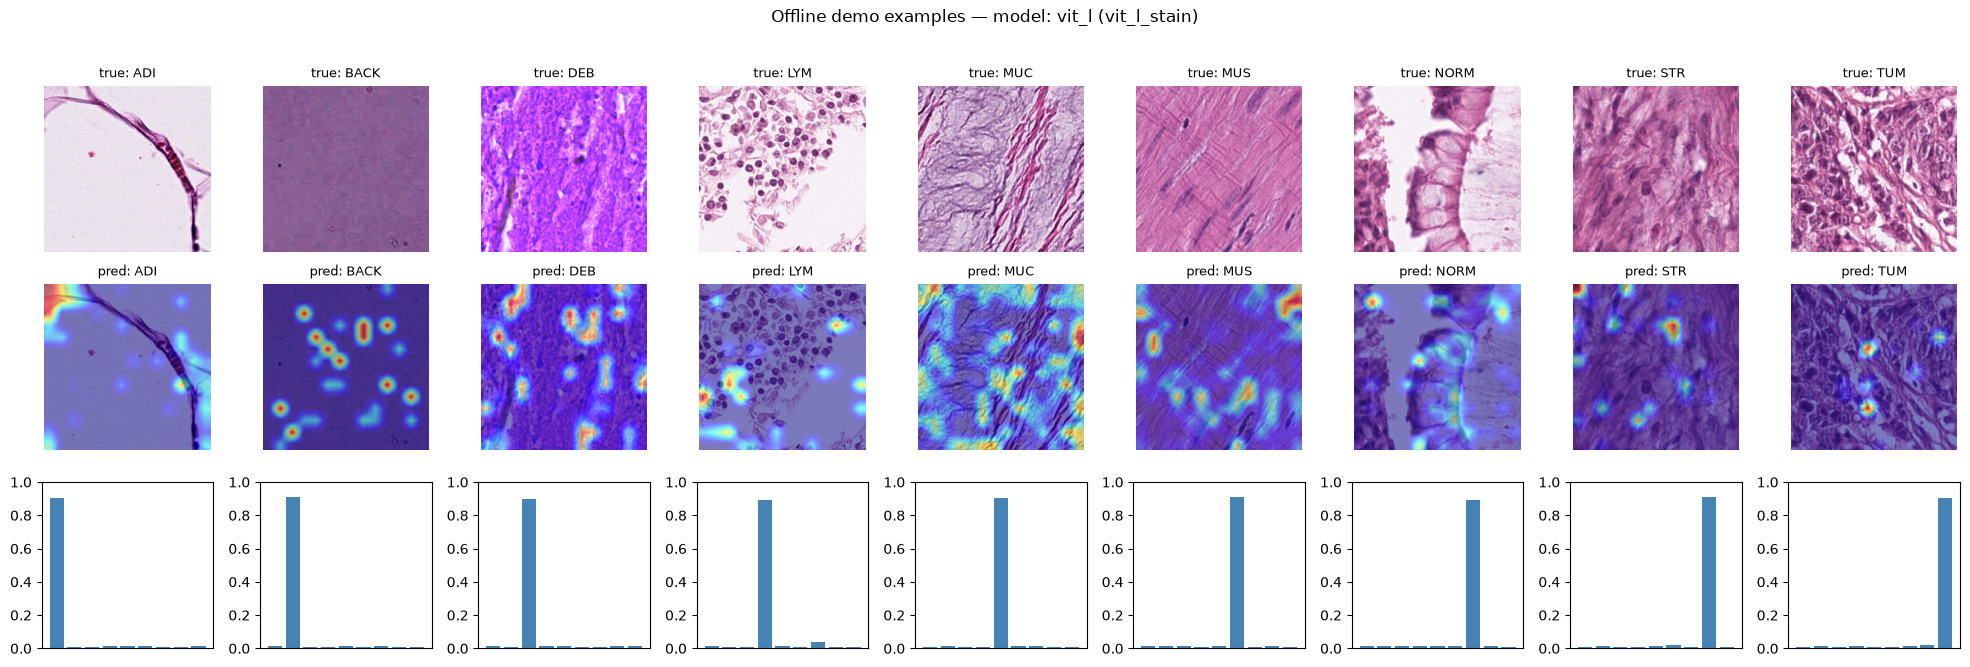

  ADI -> ADI   (conf 0.905)
 BACK -> BACK  (conf 0.910)
  DEB -> DEB   (conf 0.901)
  LYM -> LYM   (conf 0.890)
  MUC -> MUC   (conf 0.906)
  MUS -> MUS   (conf 0.907)
 NORM -> NORM  (conf 0.892)
  STR -> STR   (conf 0.909)
  TUM -> TUM   (conf 0.906)


In [3]:
# Offline demo capture: run classify() on one example per class, save a grid + predictions JSON
# so the demo's behaviour can be reviewed without a live Gradio server.
import json as _json
import matplotlib.pyplot as plt

paths = ensure_dataset(PERSIST_DIR)
VAL_DIR = paths["CRC-VAL-HE-7K"]
demo_ds = PathologyPatchDataset(VAL_DIR, classes=classes, transform=None)

OUT = PERSIST_DIR / "outputs"; OUT.mkdir(parents=True, exist_ok=True)
results = []
fig, axes = plt.subplots(3, len(classes), figsize=(2.2 * len(classes), 6.5))
for col, c in enumerate(classes):
    i = next(idx for idx, (_, l) in enumerate(demo_ds.samples) if classes[l] == c)
    path, _ = demo_ds.samples[i]
    img = Image.open(path).convert("RGB")
    label_desc, dist, overlay = classify(img)
    pred_class = label_desc.split(" — ")[0]
    pred_key = next(k for k in dist if k.startswith(pred_class))
    results.append({"true": c, "pred": pred_class, "confidence": float(dist[pred_key]), "file": str(path)})
    axes[0, col].imshow(img); axes[0, col].axis("off"); axes[0, col].set_title(f"true: {c}", fontsize=9)
    axes[1, col].imshow(overlay); axes[1, col].axis("off"); axes[1, col].set_title(f"pred: {pred_class}", fontsize=9)
    axes[2, col].bar(range(len(classes)), [dist[k] for k in dist], color="steelblue")
    axes[2, col].set_xticks([]); axes[2, col].set_ylim(0, 1)
plt.suptitle(f"Offline demo examples — model: {cfg['model']} ({RUN_NAME})", y=1.02)
plt.tight_layout()
plt.savefig(OUT / "demo_offline_examples.png", dpi=160, bbox_inches="tight")
plt.show()
_json.dump(results, open(OUT / "demo_offline_examples.json", "w"), indent=2)
for r in results:
    print(f"{r['true']:>5} -> {r['pred']:<5} (conf {r['confidence']:.3f})")


In [4]:
_ensure("gradio")
import gradio as gr
import time

with gr.Blocks(title="FINETUNING_004 — Stain-Robust Pathology Classifier") as demo:
    gr.Markdown("# FINETUNING_004 — Stain-Robust Pathology Classifier\n"
                "Upload a 224x224 H&E patch -> tissue class + confidence + Grad-CAM. "
                f"Model: **{cfg['model']}** fine-tuned on NCT-CRC-HE-100K (AMD MI300X).")
    with gr.Row():
        with gr.Column():
            inp = gr.Image(type="pil", label="H&E patch")
            mac = gr.Checkbox(label="Macenko normalize upload", value=False)
            btn = gr.Button("Classify", variant="primary")
        with gr.Column():
            out_label = gr.Markdown(label="Prediction")
            out_dist = gr.Label(num_top_classes=9, label="Class probabilities")
            out_cam = gr.Image(type="pil", label="Grad-CAM overlay")
    btn.click(classify, inputs=[inp, mac], outputs=[out_label, out_dist, out_cam])

# Non-blocking launch: prove the demo starts, then close it so notebook execution can
# finish (the offline example grid above is the artifact for the static demo). A prior
# session left a server bound to 8860, so pick a free port for this launch.
import socket
def _free_port(candidates):
    for p in candidates:
        s = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
        try:
            s.bind(("0.0.0.0", p)); return p
        except OSError:
            continue
        finally:
            s.close()
    return candidates[-1]

port = _free_port([8860, 7860, 8861, 7861, 8862])
demo.launch(server_name="0.0.0.0", server_port=port, share=False, prevent_thread_lock=True)
time.sleep(3)
print(f"Gradio demo launched successfully on port {port} (offline examples captured above).")
demo.close()


22:01:15 | INFO | HTTP Request: GET http://localhost:8861/gradio_api/startup-events "HTTP/1.1 200 OK"


22:01:15 | INFO | HTTP Request: HEAD http://localhost:8861/ "HTTP/1.1 200 OK"


* Running on local URL:  http://0.0.0.0:8861
* To create a public link, set `share=True` in `launch()`.


22:01:15 | INFO | HTTP Request: GET https://api.gradio.app/pkg-version "HTTP/1.1 200 OK"


Gradio demo launched successfully on port 8861 (offline examples captured above).
Closing server running on port: 8861
